In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import pickle

In [2]:
# Load model and selected features
with open('model_final.pkl', 'rb') as f:
    model = pickle.load(f)

with open('selected_features.pkl', 'rb') as f:
    selected_features = pickle.load(f)

# Load processed data
df = pd.read_csv('data_processed.csv')

X = df[selected_features]
y = df['TARGET']

print(f"Data loaded: {X.shape}")
print(f"Selected features: {selected_features}")

Data loaded: (36457, 16)
Selected features: ['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 'CNT_FAM_MEMBERS', 'AGE', 'YEARS_EMPLOYED', 'NAME_INCOME_TYPE_Pensioner', 'NAME_INCOME_TYPE_Working', 'NAME_EDUCATION_TYPE_Secondary / secondary special', 'NAME_FAMILY_STATUS_Single / not married', 'OCCUPATION_TYPE_Laborers', 'OCCUPATION_TYPE_Unknown']


In [3]:
# Extract the RF model from the pipeline
rf_model = model.named_steps['model']

# SHAP TreeExplainer - optimized for tree-based models
explainer = shap.TreeExplainer(rf_model)

# Calculate SHAP values on a sample (full dataset is slow)
# We use 500 samples for visualization
X_sample = X.sample(500, random_state=42)

print("Calculating SHAP values...")
shap_values = explainer.shap_values(X_sample)
print(f"SHAP values shape: {shap_values.shape}")
print("Done!")

Calculating SHAP values...
SHAP values shape: (500, 16, 2)
Done!


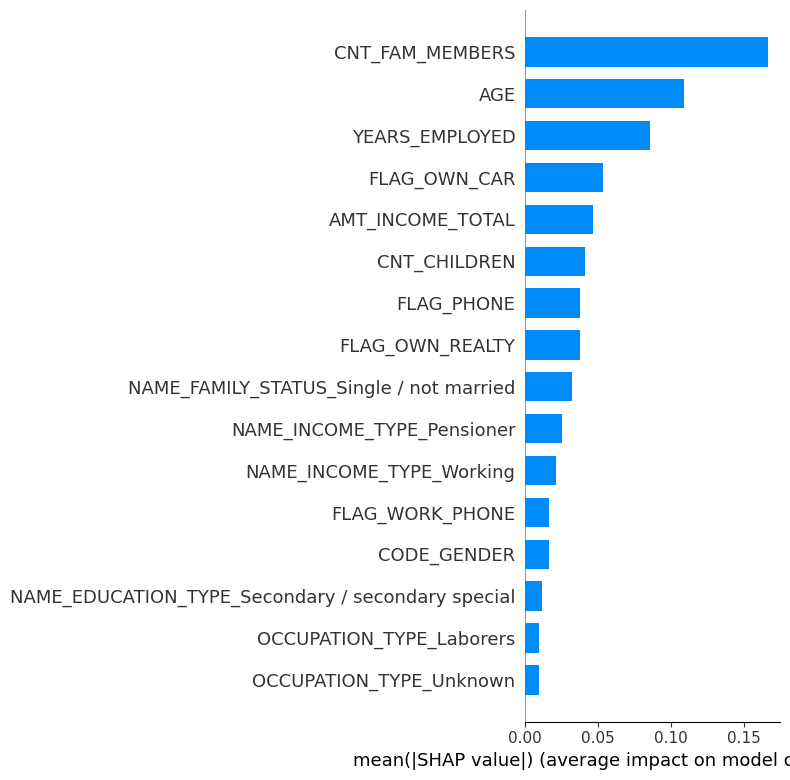

<Figure size 640x480 with 0 Axes>

In [4]:
# Class 1 = Bad client
shap_values_bad = shap_values[:, :, 1]

# Summary plot - global feature importance
plt.figure()
shap.summary_plot(shap_values_bad, X_sample, plot_type="bar", 
                  feature_names=selected_features,
                  title="SHAP - Global Feature Importance (Bad client)")
plt.tight_layout()
plt.show()

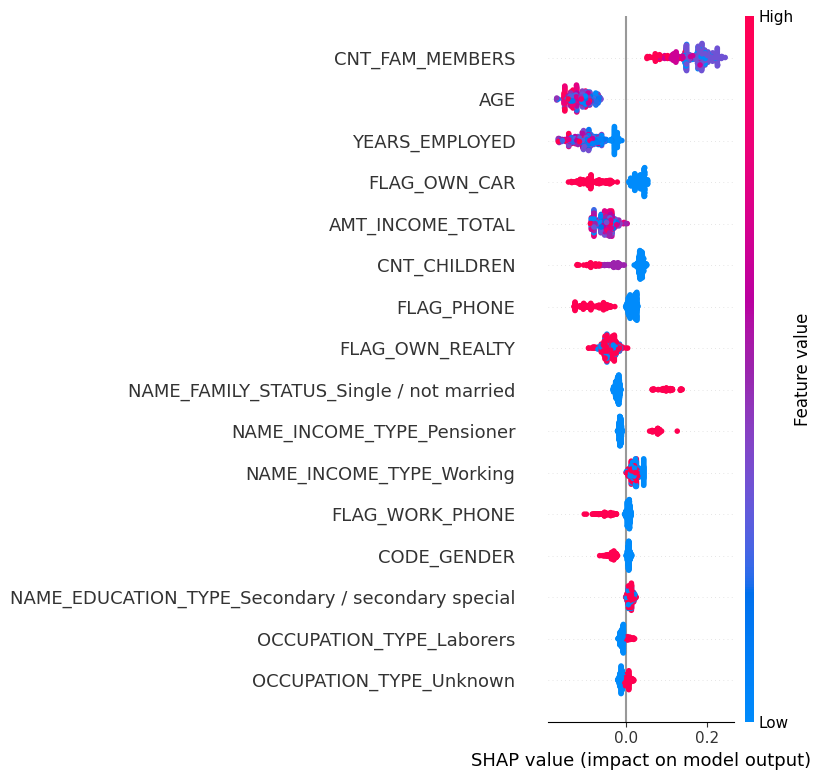

<Figure size 640x480 with 0 Axes>

In [5]:
# Beeswarm plot - direction of impact
plt.figure()
shap.summary_plot(shap_values_bad, X_sample,
                  feature_names=selected_features)
plt.tight_layout()
plt.show()

Client profile:
CODE_GENDER                                                  0
FLAG_OWN_CAR                                                 0
FLAG_OWN_REALTY                                              0
CNT_CHILDREN                                                 0
AMT_INCOME_TOTAL                                     11.547337
FLAG_WORK_PHONE                                              0
FLAG_PHONE                                                   0
CNT_FAM_MEMBERS                                            1.0
AGE                                                         67
YEARS_EMPLOYED                                             0.0
NAME_INCOME_TYPE_Pensioner                                True
NAME_INCOME_TYPE_Working                                 False
NAME_EDUCATION_TYPE_Secondary / secondary special        False
NAME_FAMILY_STATUS_Single / not married                   True
OCCUPATION_TYPE_Laborers                                 False
OCCUPATION_TYPE_Unknown                

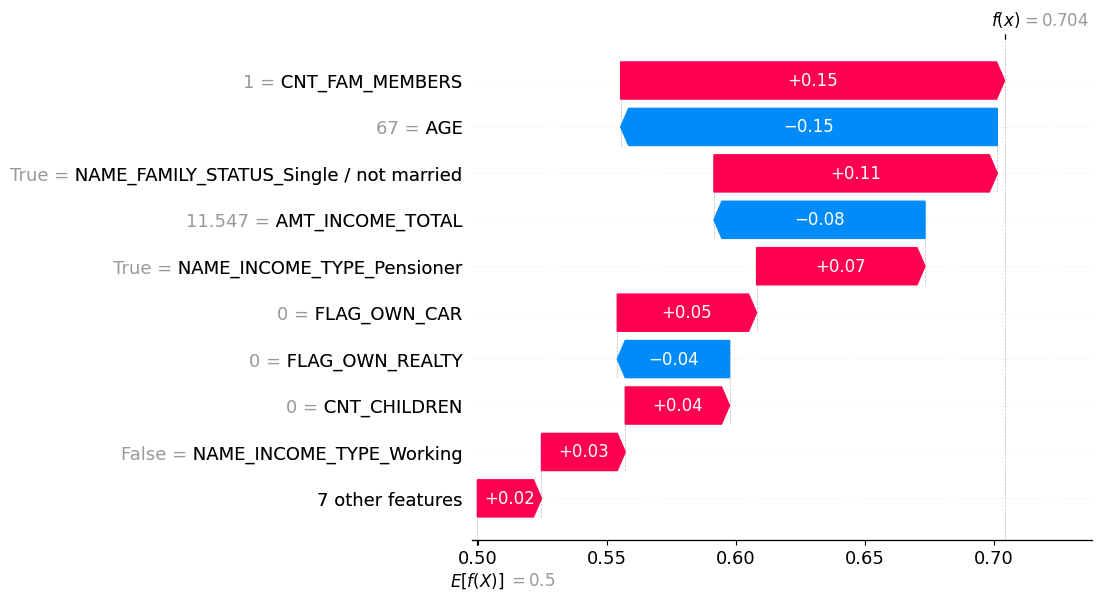

In [6]:
# Individual prediction explanation - worst bad client
# Find the client with highest predicted probability of being bad
X_sample_reset = X_sample.reset_index(drop=True)
worst_client_idx = shap_values_bad.sum(axis=1).argmax()

print(f"Client profile:")
print(X_sample_reset.iloc[worst_client_idx])

shap.waterfall_plot(shap.Explanation(
    values=shap_values_bad[worst_client_idx],
    base_values=explainer.expected_value[1],
    data=X_sample_reset.iloc[worst_client_idx],
    feature_names=selected_features
))